In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tifffile

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [3]:
import os

os.makedirs("../results", exist_ok=True)

print("results folder created")

results folder created


In [5]:
class EuroSATMultiDataset(Dataset):

    def __init__(self, root_dir):

        self.samples = []

        self.classes = sorted(
            os.listdir(root_dir)
        )

        self.class_to_idx = {
            cls: idx
            for idx, cls in enumerate(self.classes)
        }

        for cls in self.classes:

            cls_path = os.path.join(
                root_dir,
                cls
            )

            for file in os.listdir(cls_path):

                if file.endswith(".tif"):

                    self.samples.append(
                        (
                            os.path.join(
                                cls_path,
                                file
                            ),
                            self.class_to_idx[cls]
                        )
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image_path, label = self.samples[idx]

        image = tifffile.imread(image_path)

        image = image.astype(np.float32)

        # NO NORMALIZATION HERE

        image = torch.tensor(image)

        image = image.permute(2,0,1)

        return image, label

In [6]:
ms_val = "../data/EuroSATallBands/val"

val_dataset = EuroSATMultiDataset(
    ms_val
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

print(len(val_dataset))
print(val_dataset.classes)

4050
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [7]:
class MultiSpectralCNN(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                13,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128*8*8,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [8]:
model = MultiSpectralCNN()

model = model.to(device)

model.load_state_dict(
    torch.load(
        "../models/multispectral_best.pth",
        map_location=device
    )
)

model.eval()

print("Model Loaded")

Model Loaded


In [9]:
all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            preds == labels
        ).sum().item()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = 100 * correct / total

print(
    f"Validation Accuracy: {accuracy:.2f}%"
)

Validation Accuracy: 91.78%


In [11]:
import pandas as pd

pred_df = pd.DataFrame({
    "Actual": all_labels,
    "Predicted": all_preds
})

pred_df.to_csv("../results/multispectral_predictions.csv", index=False)

print("multispectral_predictions.csv saved")

multispectral_predictions.csv saved


In [12]:
print(val_dataset[0][0].min())
print(val_dataset[0][0].max())

tensor(11.)
tensor(5413.)


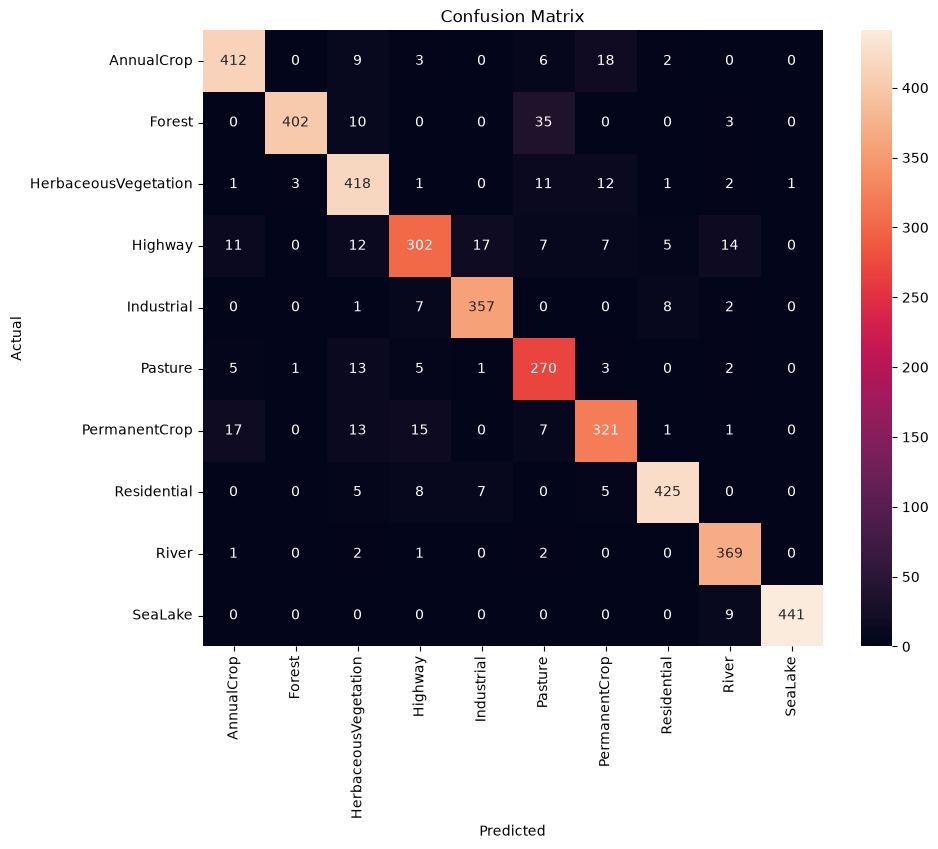

In [13]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=val_dataset.classes,
    yticklabels=val_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)
plt.savefig("confusion_matrix.png")
plt.show()

In [14]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=val_dataset.classes
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.92      0.92      0.92       450
              Forest       0.99      0.89      0.94       450
HerbaceousVegetation       0.87      0.93      0.90       450
             Highway       0.88      0.81      0.84       375
          Industrial       0.93      0.95      0.94       375
             Pasture       0.80      0.90      0.85       300
       PermanentCrop       0.88      0.86      0.87       375
         Residential       0.96      0.94      0.95       450
               River       0.92      0.98      0.95       375
             SeaLake       1.00      0.98      0.99       450

            accuracy                           0.92      4050
           macro avg       0.91      0.92      0.91      4050
        weighted avg       0.92      0.92      0.92      4050



In [15]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=val_dataset.classes
)

with open("classification_report.txt", "w") as f:
    f.write(report)

print(report)
print("Classification report saved")

                      precision    recall  f1-score   support

          AnnualCrop       0.92      0.92      0.92       450
              Forest       0.99      0.89      0.94       450
HerbaceousVegetation       0.87      0.93      0.90       450
             Highway       0.88      0.81      0.84       375
          Industrial       0.93      0.95      0.94       375
             Pasture       0.80      0.90      0.85       300
       PermanentCrop       0.88      0.86      0.87       375
         Residential       0.96      0.94      0.95       450
               River       0.92      0.98      0.95       375
             SeaLake       1.00      0.98      0.99       450

            accuracy                           0.92      4050
           macro avg       0.91      0.92      0.91      4050
        weighted avg       0.92      0.92      0.92      4050

Classification report saved


In [16]:
import os

print(os.path.exists("confusion_matrix.png"))
print(os.path.exists("classification_report.txt"))

True
True


In [17]:
import os

print(os.path.exists("../models/multispectral_best.pth"))

True
